In [1]:
import pandas as pd

In [2]:
df=pd.read_csv(r"C:\Users\selva\OneDrive\Desktop\Cars.csv")

In [3]:
df

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947
77,238,19.197888,115,150.576579,37.923113
78,263,34.000000,50,151.598513,15.769625
79,295,19.833733,119,167.944460,39.423099


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   HP      81 non-null     int64  
 1   MPG     81 non-null     float64
 2   VOL     81 non-null     int64  
 3   SP      81 non-null     float64
 4   WT      81 non-null     float64
dtypes: float64(3), int64(2)
memory usage: 3.3 KB


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
from matplotlib import pyplot as plt
import seaborn as sns

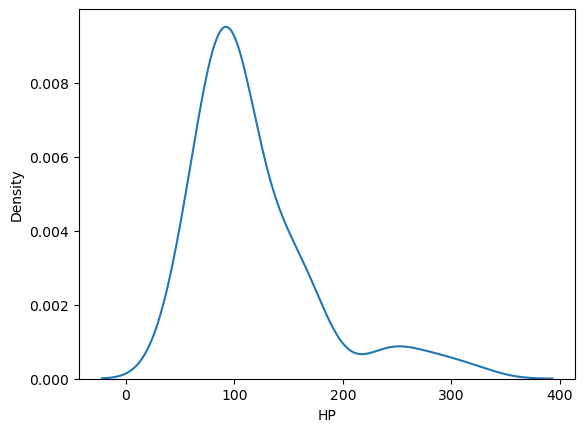

In [8]:
sns.kdeplot(df['HP'])
plt.show()

In [9]:
df.describe()  

,HP,MPG,VOL,SP,WT
count,81.000000,81.000000,81.000000,81.000000,81.000000
mean,117.469136,34.422076,98.765432,121.540272,32.412577
std,57.113502,9.131445,22.301497,14.181432,7.492813
min,49.000000,12.101263,50.000000,99.564907,15.712859
25%,84.000000,27.856252,89.000000,113.829145,29.591768
50%,100.000000,35.152727,101.000000,118.208698,32.734518
75%,140.000000,39.531633,113.000000,126.404312,37.392524
max,322.000000,53.700681,160.000000,169.598513,52.997752


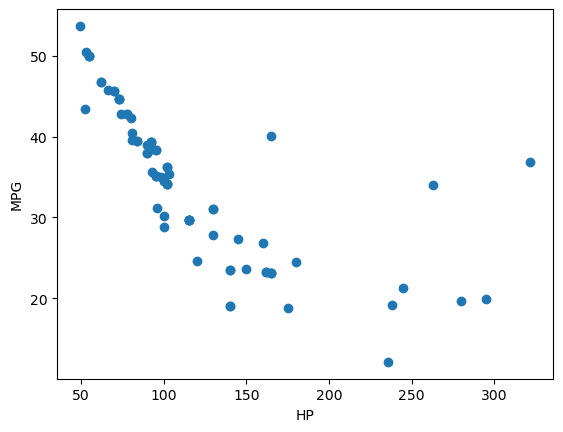

In [10]:
plt.scatter(df['HP'],df['MPG'])
plt.xlabel("HP")
plt.ylabel("MPG")
plt.show()

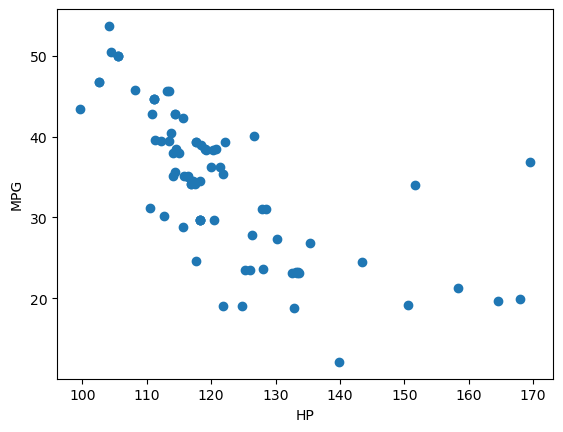

In [11]:
plt.scatter(df['SP'],df['MPG'])
plt.xlabel("HP")
plt.ylabel("MPG")
plt.show()

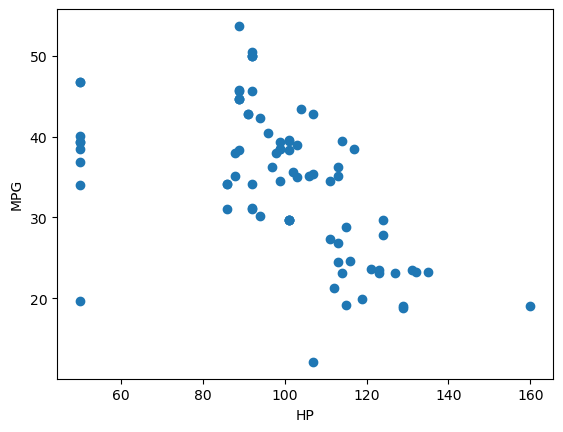

In [13]:
plt.scatter(df['VOL'],df['MPG'])
plt.xlabel("HP")
plt.ylabel("MPG")
plt.show()

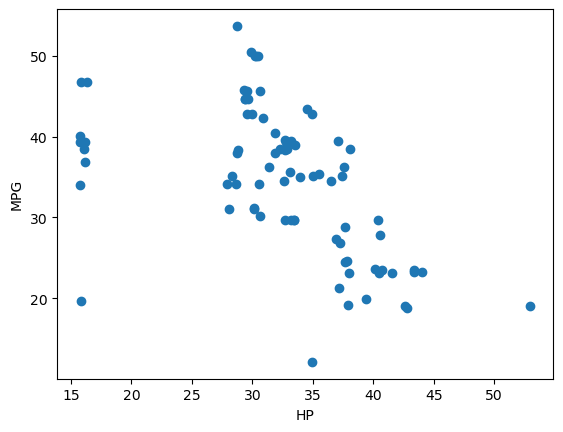

In [14]:
plt.scatter(df['WT'],df['MPG'])
plt.xlabel("HP")
plt.ylabel("MPG")
plt.show()

In [ ]:
Lineraity test is failed

In [ ]:
No autocorrelation is present /data is independent data passed this test

In [20]:
x=df.drop(columns='MPG')
x

,HP,VOL,SP,WT
0,49,89,104.185353,28.762059
1,55,92,105.461264,30.466833
2,55,92,105.461264,30.193597
3,70,92,113.461264,30.632114
4,53,92,104.461264,29.889149
...,...,...,...,...
76,322,50,169.598513,16.132947
77,238,115,150.576579,37.923113
78,263,50,151.598513,15.769625
79,295,119,167.944460,39.423099


In [21]:
y=df['MPG']
y

0     53.700681
1     50.013401
2     50.013401
3     45.696322
4     50.504232
        ...    
76    36.900000
77    19.197888
78    34.000000
79    19.833733
80    12.101263
Name: MPG, Length: 81, dtype: float64

In [23]:
cr=x.corr()
cr

,HP,VOL,SP,WT
HP,1.000000,0.077459,0.973848,0.076513
VOL,0.077459,1.000000,0.102170,0.999203
SP,0.973848,0.102170,1.000000,0.102439
WT,0.076513,0.999203,0.102439,1.000000


In [ ]:
HP,SP are correlated 
VOL,WT are correlated
so data fail No Multicolinearty test

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,shuffle=True,random_state=12)
x_train,x_test,y_train,y_test

(     HP  VOL          SP         WT
 59  100  115  115.576579  37.662874
 63  140  123  125.312342  40.722831
 28   52  104   99.564907  34.483207
 40   95  113  116.392639  37.392524
 43   95   88  114.093383  28.343976
 ..  ...  ...         ...        ...
 3    70   92  113.461264  30.632114
 2    55   92  105.461264  30.193597
 6    55   92  105.461264  30.308480
 27   92   99  119.105055  32.835069
 75  175  129  132.864163  42.778219
 
 [64 rows x 4 columns],
      HP  VOL          SP         WT
 57  115  101  118.288996  32.734518
 12   92   99  122.105055  32.813592
 14   66   89  108.185353  29.347279
 7    62   50  102.598513  15.847758
 42  102   92  117.461264  30.527427
 41   95  106  115.748847  35.027176
 8    62   50  102.598513  16.359484
 68  165  123  133.312342  40.472042
 29  103  107  121.840817  35.549360
 17   92   50  117.598513  16.194122
 26   92  117  120.760520  38.062823
 19   90  103  118.472936  33.516974
 80  236  107  139.840817  34.948615
 21   74  10

In [26]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((64, 4), (17, 4), (64,), (17,))

In [27]:
from sklearn.linear_model import LinearRegression

In [29]:
mlr=LinearRegression()
mlr.fit(x_train,y_train)
y_train_pred=mlr.predict(x_train)
y_test_pred=mlr.predict(x_test)


In [30]:
y_train_pred

array([31.84891407, 26.26544167, 37.90370433, 33.86217856, 38.5138239 ,
       36.30847247, 22.62323268, 28.05889807, 37.18009477, 19.00654776,
       25.76354891, 26.56197102, 23.44572669, 21.77337396, 41.83050633,
       39.38123004, 25.97959426, 38.86711093, 49.60253102, 42.43953488,
       36.62860809, 35.62412115, 42.04599212, 28.4999423 , 35.68327873,
       41.99570757, 40.27270958, 48.6651069 , 13.88294336, 33.9231852 ,
       35.75660232, 30.16637073, 33.68869062, 40.90874672, 36.47557668,
       29.93194311, 38.5521749 , 41.26459975, 33.53611171, 17.10153823,
       41.53420536, 37.24797144, 28.02219808, 34.14665787, 34.54639253,
       39.08471651, 39.74654901, 24.62117109, 37.56930688, 21.46948998,
       43.33742688, 37.00772771, 41.84084566, 43.31530465, 28.47543643,
       33.7035955 , 37.73223515, 37.83186511, 23.38197409, 42.72595522,
       42.25237994, 42.33106975, 38.90178996, 21.05650982])

In [31]:
y_test_pred

array([33.20771927, 40.02289413, 42.01631654, 49.69925455, 38.07665913,
       35.2798795 , 50.049764  , 24.3631194 , 35.95220006, 49.90431366,
       34.6709292 , 37.63508988, 17.03568886, 36.86927074, 28.58666317,
       39.72128407, 31.65402822])

In [32]:
from sklearn.metrics import r2_score

In [33]:
train_r2=r2_score(y_train_pred,y_train)
train_r2

0.685704565135205

In [34]:
test_r2=r2_score(y_test_pred,y_test)
test_r2

0.6736097690475513

In [35]:
test_error=y_test-y_test_pred
test_error   #checking error difference .it should be done on test data 

57    -3.577783
12    -0.668800
14     3.718576
7     -2.982700
42    -4.005991
41    -0.127153
8     -3.333210
68    -1.259948
29    -0.548008
17   -10.550220
26     3.740074
19     1.266744
80    -4.934426
21     5.959209
54    -1.734384
23     0.753439
70   -11.975522
Name: MPG, dtype: float64

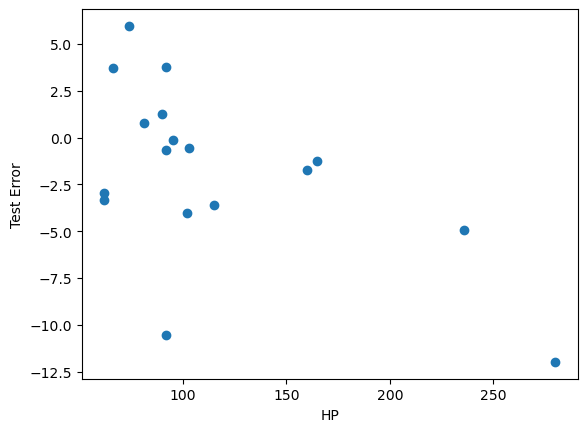

In [36]:
plt.scatter(x_test['HP'],test_error)
plt.xlabel('HP')
plt.ylabel('Test Error')
plt.show()

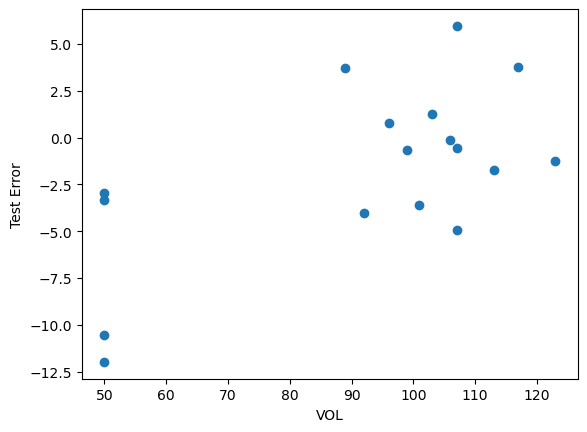

In [38]:
plt.scatter(x_test['VOL'],test_error)
plt.xlabel('VOL')
plt.ylabel('Test Error')
plt.show()

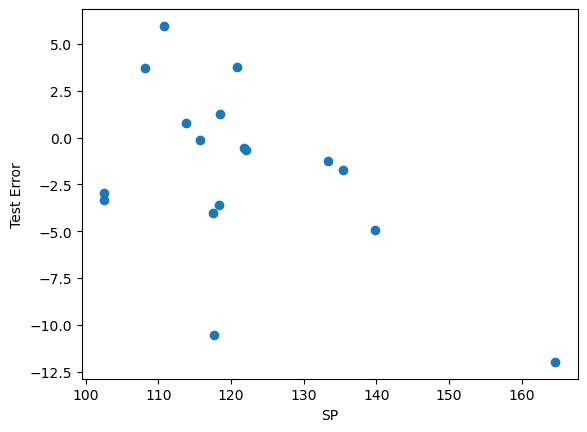

In [39]:
plt.scatter(x_test['SP'],test_error)
plt.xlabel('SP')
plt.ylabel('Test Error')
plt.show()

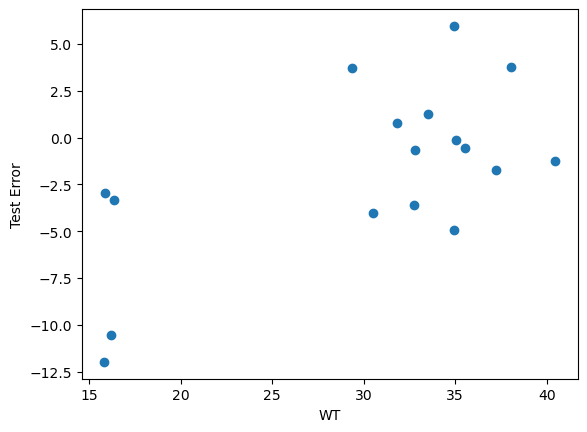

In [40]:
plt.scatter(x_test['WT'],test_error)
plt.xlabel('WT')
plt.ylabel('Test Error')
plt.show()

In [ ]:
Homoscedasticity test is failed

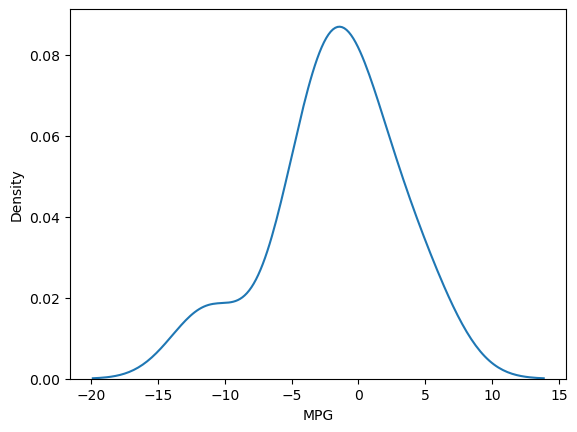

In [42]:
sns.kdeplot(test_error)
plt.show()

In [44]:
import pickle

pickle.dump(mlr, open("MLR", "wb"))